In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("FoodRecommendationSystem").getOrCreate() ###Create Spark Session

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Initialize Spark Session & Load Interaction Data
df = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("escape", '"')
    .load("/content/drive/MyDrive/RAW_interactions.csv")
)

In [5]:
# Verify loaded record count and schema
print(f"Total records loaded: {df.count()}")
df.show(10)
df.printSchema()

Total records loaded: 1132367
+----------+---------+----------+------+--------------------+
|   user_id|recipe_id|      date|rating|              review|
+----------+---------+----------+------+--------------------+
|     38094|    40893|2003-02-17|     4|Great with a sala...|
|   1293707|    40893|2011-12-21|     5|So simple, so del...|
|      8937|    44394|2002-12-01|     4|This worked very ...|
|    126440|    85009|2010-02-27|     5|I made the Mexica...|
|     57222|    85009|2011-10-01|     5|Made the cheddar ...|
|     52282|   120345|2005-05-21|     4|very very sweet. ...|
|    124416|   120345|2011-08-06|     0|Just an observati...|
|2000192946|   120345|2015-05-10|     2|This recipe was O...|
|     76535|   134728|2005-09-02|     4|          Very good!|
|    273745|   134728|2005-12-22|     5|Better than the r...|
+----------+---------+----------+------+--------------------+
only showing top 10 rows
root
 |-- user_id: integer (nullable = true)
 |-- recipe_id: integer (nullabl

In [6]:
from pyspark.sql.functions import col

# Type Casting: Strings to Numeric Types
df_clean = df.select(
    col("user_id").cast("integer"),
    col("recipe_id").cast("integer"),
    col("rating").cast("float"),
).dropna()

#  verify Schema
df_clean.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- recipe_id: integer (nullable = true)
 |-- rating: float (nullable = true)



In [7]:
# Read the raw recipes dataset containing recipe titles
recipes_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/content/drive/MyDrive/RAW_recipes.csv")

In [8]:
# Extract essential columns and rename 'id' to 'recipe_id' for joining
recipe_names = recipes_df.select("id", "name").withColumnRenamed("id", "recipe_id")

In [9]:
# Merge interactions with recipe names using a left join
df_with_names = df_clean.join(recipe_names, on="recipe_id", how="left")

In [10]:
# Display the first 5 records of the joined DataFrame
from pyspark.sql.functions import col, expr

# Re-create recipe_names with robust type casting for recipe_id
recipe_names_corrected = recipes_df.select(
    expr("try_cast(id as int) as recipe_id"), # Cast 'id' to integer, handling malformed data
    col("name")
).dropna(subset=["recipe_id"]) # Drop rows where recipe_id became null due to try_cast failure

# Re-merge interactions with corrected recipe names using a left join
df_with_names_corrected = df_clean.join(recipe_names_corrected, on="recipe_id", how="left")

# Display the first 5 records of the joined DataFrame
df_with_names_corrected.show(5)

+---------+-------+------+--------------------+
|recipe_id|user_id|rating|                name|
+---------+-------+------+--------------------+
|    40893|  38094|   4.0|white bean   gree...|
|    40893|1293707|   5.0|white bean   gree...|
|   120345|  52282|   4.0| sugared raspberries|
|    44394|   8937|   4.0|devilicious cooki...|
|    85009| 126440|   5.0|baked potato topp...|
+---------+-------+------+--------------------+
only showing top 5 rows


In [11]:
df

DataFrame[user_id: int, recipe_id: int, date: date, rating: int, review: string]

In [12]:
df_with_names

DataFrame[recipe_id: int, user_id: int, rating: float, name: string]

###Part A

####Data Cleaning and PreProcessing

In [13]:
from pyspark.sql.functions import col, count, when, split, explode, desc, trim, lower, avg, round

In [23]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, when, expr

# Rebuild df_clean from the corrected join
df_clean = df_with_names_corrected.select("user_id", "recipe_id", "name", "rating")

n_before = df_clean.count()
n_zero = df_clean.filter(col("rating") == 0).count()

# Robust type casting: malformed strings become nulls (no NumberFormatException)
df_clean = (
    df_clean
    .withColumn("user_id", expr("try_cast(user_id as int)"))
    .withColumn("recipe_id", expr("try_cast(recipe_id as int)"))
    .withColumn("rating", expr("try_cast(rating as float)"))
    # DROP incomplete rows instead of filling them with fake values (0 / "Unknown Recipe")
    .dropna(subset=["user_id", "recipe_id", "name", "rating"])
    # In Food.com a rating of 0 means "reviewed but not rated", not a 0-star score
    .filter(col("rating") > 0)
)

n_after = df_clean.count()
print(f"Rows before cleaning        : {n_before:,}")
print(f"Rows with rating == 0       : {n_zero:,}  (removed: 'no rating', not a real score)")
print(f"Rows after cleaning         : {n_after:,}")

print("Verification of nulls:")
df_clean.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in df_clean.columns]
).show()

Rows before cleaning        : 1,132,367
Rows with rating == 0       : 60,847  (removed: 'no rating', not a real score)
Rows after cleaning         : 1,071,520
Verification of nulls:
+-------+---------+----+------+
|user_id|recipe_id|name|rating|
+-------+---------+----+------+
|      0|        0|   0|     0|
+-------+---------+----+------+



####Exploratory Data Analysis and Visualization

Global average rating (rating > 0): 4.66
Top Recipe Categories/Tags by Weighted Rating:
+-------------------+----------+------------+------------+---------------+
|tag_individual     |avg_rating|rating_count|recipe_count|weighted_rating|
+-------------------+----------+------------+------------+---------------+
|reynolds-wrap      |4.97      |838         |67          |4.94           |
|hidden-valley-ranch|4.97      |978         |100         |4.94           |
|simply-potatoes    |4.93      |1511        |256         |4.91           |
|a1-sauce           |4.95      |335         |39          |4.88           |
|ragu-recipe-contest|4.98      |213         |42          |4.88           |
|mashed-potatoes    |4.9       |338         |97          |4.85           |
|non-alcoholic      |4.86      |727         |300         |4.84           |
|simply-potatoes2   |5.0       |104         |6           |4.83           |
|whole-turkey       |4.82      |1452        |183         |4.81           |
|meatballs  

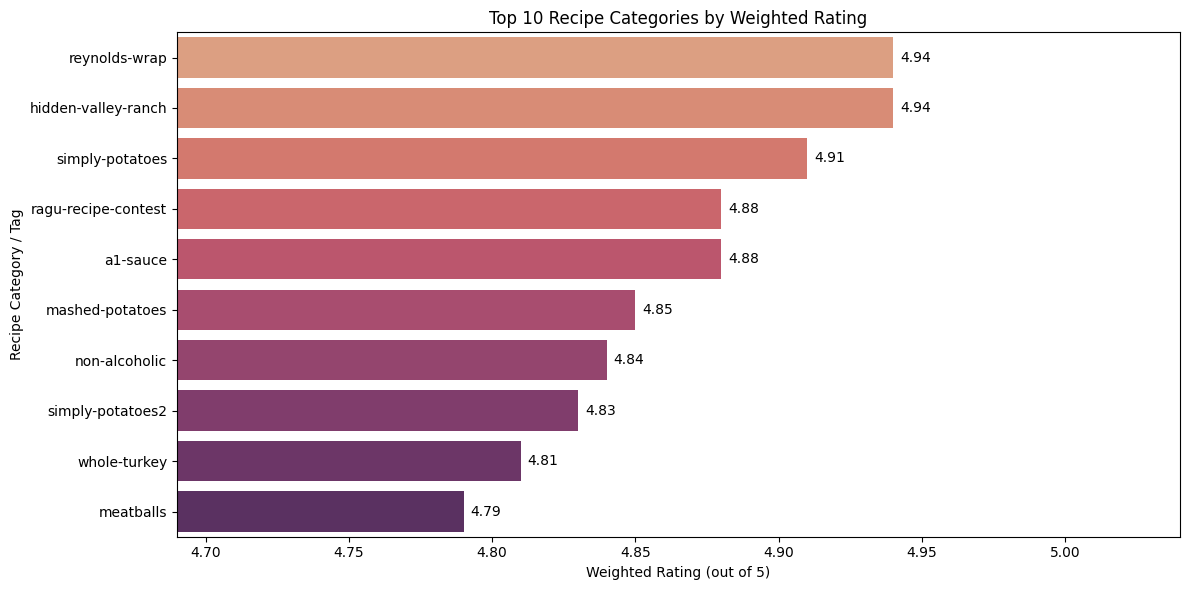

In [24]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, expr, desc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Recipe tags + ingredients. Quotes/brackets are stripped HERE, in Spark, before any splitting.
recipes_with_tags = (
    recipes_df.select(
        expr("try_cast(id as int) as recipe_id"), col("tags"), col("ingredients")
    )
    .dropna(subset=["recipe_id", "tags"])
    .withColumn("tags", F.regexp_replace(col("tags"), r"[\[\]']", ""))
)

# Generic "folder" tags that appear on almost every recipe carry no information
META_TAGS = [
    "preparation", "course", "time-to-make", "dietary",
    "main-ingredient", "occasion", "cuisine", "low-in-something",
]

df_with_tags_and_ratings = df_clean.join(
    recipes_with_tags.select("recipe_id", "tags"), on="recipe_id", how="inner"
)

recipe_tags_df = (
    df_with_tags_and_ratings
    .withColumn("tag_individual", F.explode(F.split(col("tags"), ",")))
    .withColumn("tag_individual", F.trim(col("tag_individual")))
    .filter((col("tag_individual") != "") & (~col("tag_individual").isin(META_TAGS)))
)

# Weighted (IMDb-style) rating: pulls tags with few ratings toward the global average
global_avg = df_clean.agg(F.avg("rating")).first()[0]
M = 100  # minimum ratings needed for a tag's own average to be fully trusted

tag_ratings = (
    recipe_tags_df.groupBy("tag_individual")
    .agg(
        F.round(F.avg("rating"), 2).alias("avg_rating"),
        F.count("rating").alias("rating_count"),
        F.countDistinct("recipe_id").alias("recipe_count"),  # real distinct recipes
    )
    .filter((col("rating_count") >= M) & (col("recipe_count") >= 5))
    .withColumn(
        "weighted_rating",
        F.round(
            (col("rating_count") / (col("rating_count") + F.lit(M))) * col("avg_rating")
            + (F.lit(M) / (col("rating_count") + F.lit(M))) * F.lit(global_avg),
            2,
        ),
    )
    .orderBy(desc("weighted_rating"))
)

print(f"Global average rating (rating > 0): {global_avg:.2f}")
print("Top Recipe Categories/Tags by Weighted Rating:")
tag_ratings.show(10, truncate=False)

pd_tag_ratings = tag_ratings.limit(10).toPandas()

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x="weighted_rating", y="tag_individual", hue="tag_individual",
    data=pd_tag_ratings, palette="flare", legend=False,
)
plt.xlabel("Weighted Rating (out of 5)")
plt.ylabel("Recipe Category / Tag")
plt.title("Top 10 Recipe Categories by Weighted Rating")
plt.xlim(pd_tag_ratings["weighted_rating"].min() - 0.1, pd_tag_ratings["weighted_rating"].max() + 0.1)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha="left", va="center", xytext=(5, 0), textcoords="offset points",
    )

plt.tight_layout()
plt.show()

In [25]:
from pyspark.sql.functions import col, year, avg, round

# Extract year from date & compute yearly trends (unrated reviews, rating == 0, excluded)
df_with_year = (
    df.withColumn("rating", col("rating").cast("float"))
    .filter(col("rating") > 0)
    .withColumn("year", year(col("date")))
)

yearly_trends = (
    df_with_year.groupBy("year")
    .agg(round(avg("rating"), 2).alias("avg_rating"), count("rating").alias("n_ratings"))
    .orderBy("year")
)

print("Yearly Rating Trends:")
yearly_trends.show(30)

Yearly Rating Trends:
+----+----------+---------+
|year|avg_rating|n_ratings|
+----+----------+---------+
|2000|      4.27|      100|
|2001|      4.42|     2622|
|2002|      4.65|    20022|
|2003|      4.68|    32035|
|2004|      4.68|    44676|
|2005|      4.72|    64702|
|2006|      4.69|    87918|
|2007|       4.6|   139350|
|2008|      4.66|   161251|
|2009|       4.7|   153437|
|2010|       4.7|   101668|
|2011|      4.69|    66272|
|2012|      4.68|    52094|
|2013|      4.66|    45142|
|2014|      4.62|    27222|
|2015|      4.51|    20881|
|2016|      4.51|    15877|
|2017|      4.53|    20160|
|2018|      4.51|    16091|
+----+----------+---------+



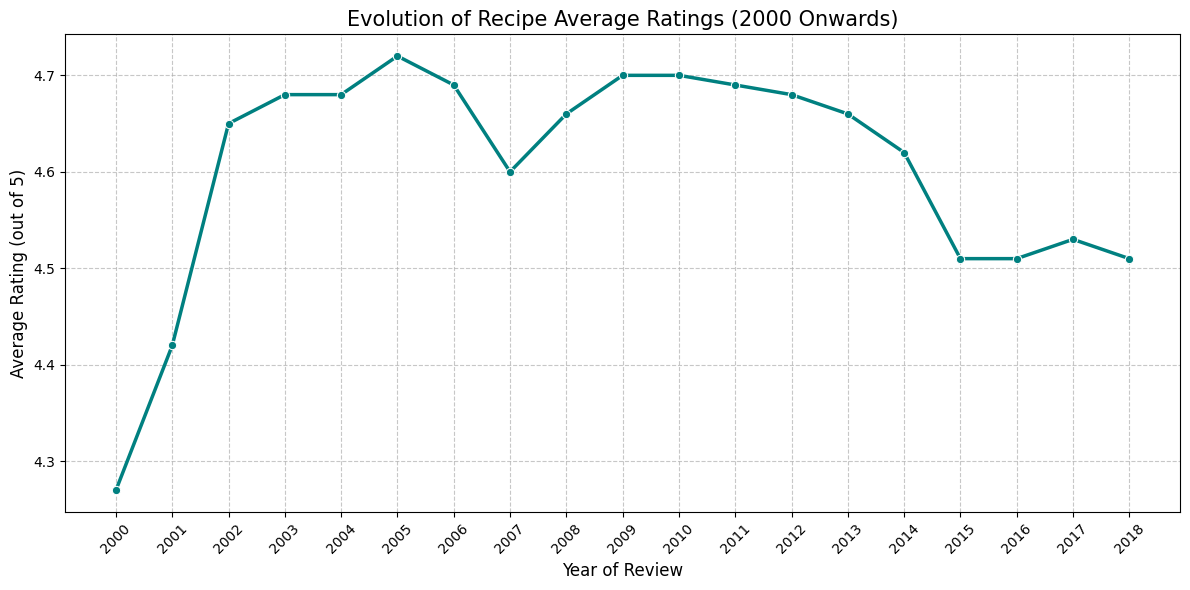

In [26]:
#Filter Data & Convert to Pandas for Visualization
# Filter for ratings post-2000 and collect to Pandas DataFrame
yearly_avg_rating = (
    df_with_year.filter(col("year") >= 2000)
    .groupBy("year")
    .agg(round(avg("rating"), 2).alias("avg_rating"))
    .orderBy("year")
    .toPandas()
)

#  Line Chart Visualization
plt.figure(figsize=(12, 6))

# Plot average recipe ratings over time
sns.lineplot(
    data=yearly_avg_rating,
    x="year",
    y="avg_rating",
    marker="o",
    color="teal",
    linewidth=2.5,
)

plt.title("Evolution of Recipe Average Ratings (2000 Onwards)", fontsize=15)
plt.xlabel("Year of Review", fontsize=12)
plt.ylabel("Average Rating (out of 5)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Format X-axis ticks to display integer years cleanly
plt.xticks(yearly_avg_rating["year"], rotation=45)

plt.tight_layout()
plt.show()

Top 10 Highest Rated Recipes (min. 100 reviews):
+------------------------------------------------------------+----------+------------+
|name                                                        |avg_rating|review_count|
+------------------------------------------------------------+----------+------------+
|bacon lattice tomato muffins  rsc                           |5.0       |192         |
|mexican stack up  rsc                                       |4.99      |217         |
|uncle bill s method for cooking turkey                      |4.97      |175         |
|refreshing mojito  by the pitcher mojitos                   |4.97      |106         |
|chicken pot pie with 2 crusts                               |4.96      |193         |
|brown sugar bundt cake                                      |4.96      |117         |
|pan release  professional pan coating  better than pam spray|4.95      |206         |
|cheesy ham and potato soup                                  |4.95      |171     

/tmp/ipykernel_4752/2788022402.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="avg_rating", y="name", data=top_rated, palette="rocket")


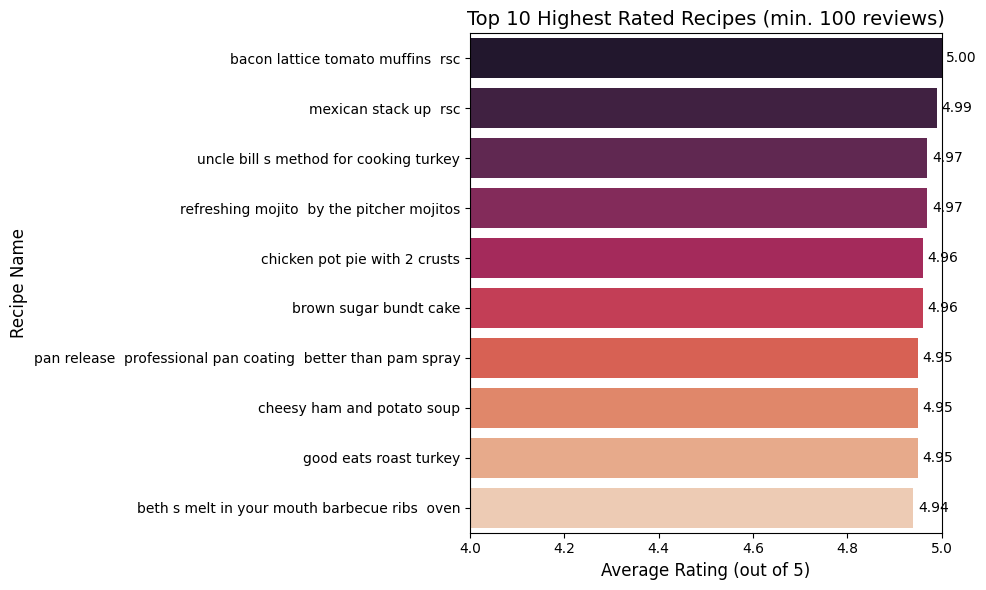

In [27]:
from pyspark.sql.functions import col, count, avg, round, desc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Compute Average Ratings and Review Counts per Recipe
# Group by recipe name to calculate average rating and total review count
recipe_stats = (
    df_clean.groupBy("recipe_id", "name")
    .agg(
        round(avg("rating"), 2).alias("avg_rating"),
        count("rating").alias("review_count"),
    )
    .filter(col("review_count") > 100)  # Filter recipes with a minimum of 100 reviews
    .orderBy(desc("avg_rating"), desc("review_count"))
)

# Extract top 10 highest-rated recipes
top_rated_recipes_spark = recipe_stats.select(
    "name", "avg_rating", "review_count"
).limit(10)

print("Top 10 Highest Rated Recipes (min. 100 reviews):")
top_rated_recipes_spark.show(truncate=False)

# Convert Spark DataFrame to Pandas for visualization
top_rated = top_rated_recipes_spark.toPandas()


#  Horizontal Bar Plot Visualization
plt.figure(figsize=(10, 6))

# Create horizontal barplot for top recipes
ax = sns.barplot(x="avg_rating", y="name", data=top_rated, palette="rocket")

# Zoom in on high scores to highlight minor differences (e.g., 4.0 to 5.0)
plt.xlim(4.0, 5.0)
plt.title(
    "Top 10 Highest Rated Recipes (min. 100 reviews)", fontsize=14
)
plt.xlabel("Average Rating (out of 5)", fontsize=12)
plt.ylabel("Recipe Name", fontsize=12)

# Add exact rating value labels on the bars
for index, value in enumerate(top_rated.avg_rating):
    plt.text(value + 0.01, index, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

Top 5 Most Reviewed Recipes (All Time):
+-------------------------------------------------+------------+----------+
|name                                             |review_count|avg_rating|
+-------------------------------------------------+------------+----------+
|to die for crock pot roast                       |1496        |4.59      |
|crock pot chicken with black beans   cream cheese|1488        |4.48      |
|best banana bread                                |1401        |4.82      |
|creamy cajun chicken pasta                       |1359        |4.84      |
|best ever banana cake with cream cheese frosting |1194        |4.79      |
+-------------------------------------------------+------------+----------+



/tmp/ipykernel_4752/3490067058.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


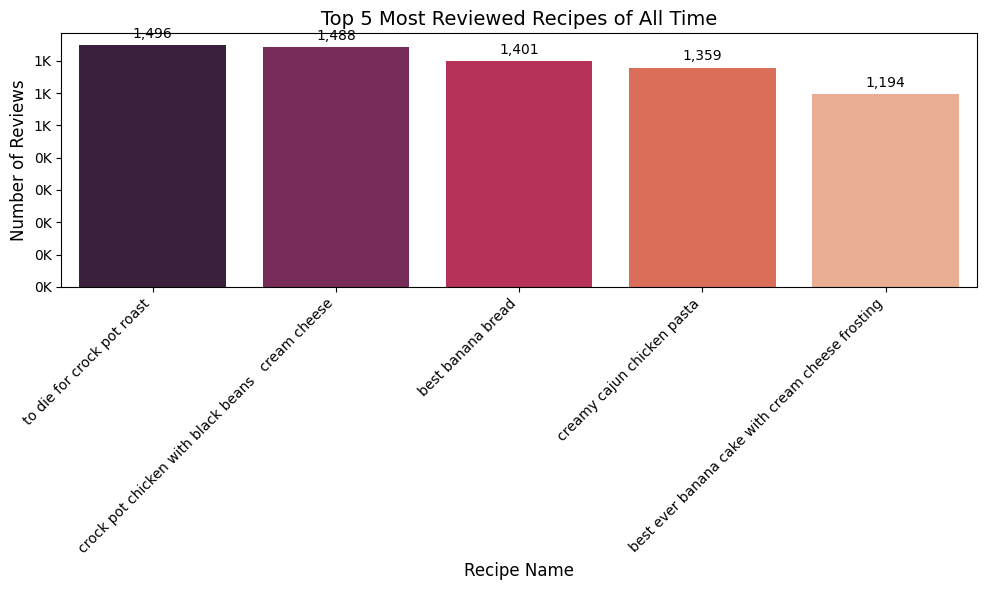

In [28]:
from matplotlib.ticker import FuncFormatter

# Compute Review Counts & Extract Top 5 Most Reviewed Recipes
print("Top 5 Most Reviewed Recipes (All Time):")

# Group by recipe to count total user interactions/reviews
recipe_engagement = df_clean.groupBy("recipe_id", "name").agg(
    count("rating").alias("review_count"),
    round(avg("rating"), 2).alias("avg_rating"),
)

# Extract top 5 most reviewed recipes in Spark
top_reviewed_spark = recipe_engagement.select(
    "name", "review_count", "avg_rating"
).orderBy(desc("review_count")).limit(5)

top_reviewed_spark.show(truncate=False)

# Collect top 5 most reviewed recipes to Pandas
top_5_views = top_reviewed_spark.toPandas()

#  Bar Chart Visualization
plt.figure(figsize=(10, 6))

# Create barplot for top 5 most popular recipes
ax = sns.barplot(
    x="name", y="review_count", data=top_5_views, palette="rocket"
)

plt.title("Top 5 Most Reviewed Recipes of All Time", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Reviews", fontsize=12)
plt.xlabel("Recipe Name", fontsize=12)

# Format Y-axis tick values to show thousands cleanly (e.g., 2K)
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{int(x/1000)}K" if x < 1e6 else f"{x/1e6:.1f}M"
    )
)

# Annotate exact review counts on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

Recipe Categories/Tags with the Highest Cumulative Reviews:
+------------------+-------------+
|tag               |total_reviews|
+------------------+-------------+
|easy              |599334       |
|equipment         |474171       |
|main-dish         |365909       |
|60-minutes-or-less|325687       |
|number-of-servings|321893       |
|meat              |304282       |
|taste-mood        |295120       |
|north-american    |269358       |
|30-minutes-or-less|254047       |
|vegetables        |248804       |
+------------------+-------------+
only showing top 10 rows


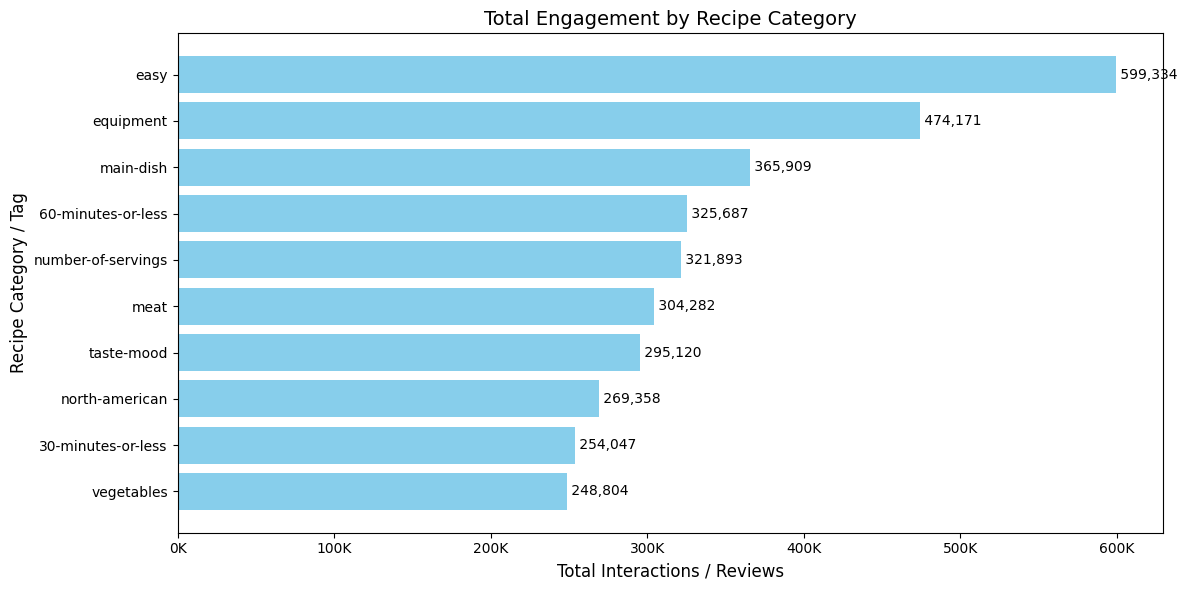

In [29]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, desc
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

print("Recipe Categories/Tags with the Highest Cumulative Reviews:")

tag_views = (
    df_with_tags_and_ratings
    .withColumn("tag", F.explode(F.split(col("tags"), ",")))
    .withColumn("tag", F.trim(col("tag")))
    .filter((col("tag") != "") & (~col("tag").isin(META_TAGS)))
    .groupBy("tag")
    .agg(count("rating").alias("total_reviews"))
    .orderBy(desc("total_reviews"))
)

tag_views.show(10, truncate=False)
pd_tag_views = tag_views.limit(10).toPandas()

plt.figure(figsize=(12, 6))
ax = plt.gca()
bars = ax.barh(pd_tag_views["tag"], pd_tag_views["total_reviews"], color="skyblue")

plt.xlabel("Total Interactions / Reviews", fontsize=12)
plt.ylabel("Recipe Category / Tag", fontsize=12)
plt.title("Total Engagement by Recipe Category", fontsize=14)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1000)}K" if x < 1e6 else f"{x/1e6:.1f}M")
)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f" {int(width):,}",
        (width, bar.get_y() + bar.get_height() / 2.0),
        ha="left", va="center", fontsize=10,
    )

plt.tight_layout()
plt.show()

In [31]:
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import functions as F
from pyspark.sql.functions import avg, col, count, round

# Recipe-level features (unrated reviews already removed in df_clean)
recipe_features_df = (
    df_clean.groupBy("recipe_id", "name")
    .agg(
        round(avg("rating"), 2).alias("avg_rating"),
        count("rating").alias("review_count"),
    )
    # review_count is heavily right-skewed -> log scale so a few huge recipes don't dominate
    .withColumn("log_reviews", F.log1p(col("review_count")))
)

features = ["avg_rating", "log_reviews"]

assembler = VectorAssembler(inputCols=features, outputCol="raw_features")
feat_df = assembler.transform(recipe_features_df)

scaler = StandardScaler(inputCol="raw_features", outputCol="features")
final_df = scaler.fit(feat_df).transform(feat_df).cache()

# Choose k with the silhouette score instead of guessing
evaluator = ClusteringEvaluator(
    featuresCol="features", predictionCol="prediction",
    metricName="silhouette", distanceMeasure="squaredEuclidean",
)
silhouettes = {}
for k in range(2, 7):
    m = KMeans(k=k, seed=1).fit(final_df)
    silhouettes[k] = evaluator.evaluate(m.transform(final_df))
    print(f"k={k}  silhouette={silhouettes[k]:.3f}")

best_k = max(silhouettes, key=silhouettes.get)
print(f"Best k by silhouette: {best_k}")

model = KMeans(k=best_k, seed=1).fit(final_df)
predictions = model.transform(final_df)

print("Recipe Segmentation via K-Means Clustering:")
predictions.select("name", "avg_rating", "review_count", "prediction").show(10, truncate=False)

k=2  silhouette=0.734
k=3  silhouette=0.552
k=4  silhouette=0.557
k=5  silhouette=0.663
k=6  silhouette=0.649
Best k by silhouette: 2
Recipe Segmentation via K-Means Clustering:
+-------------------------------------------------+----------+------------+----------+
|name                                             |avg_rating|review_count|prediction|
+-------------------------------------------------+----------+------------+----------+
|seared salmon with horseradish tomato vinaigrette|3.67      |3           |1         |
|7 up cake                                        |5.0       |1           |0         |
|hamantaschen cookies  haman s hats               |5.0       |1           |0         |
|dutch buttercake                                 |4.5       |2           |0         |
|english cream scones                             |4.0       |2           |0         |
|buttery drop cookies                             |5.0       |1           |0         |
|mom s excellent creamy cauliflower sou

K-Means Recipe Cluster Profiles:
+----------+------------------+-------------------+
|prediction|cluster_avg_rating|cluster_avg_reviews|
+----------+------------------+-------------------+
|0         |4.71              |4.94               |
|1         |2.83              |1.8                |
+----------+------------------+-------------------+



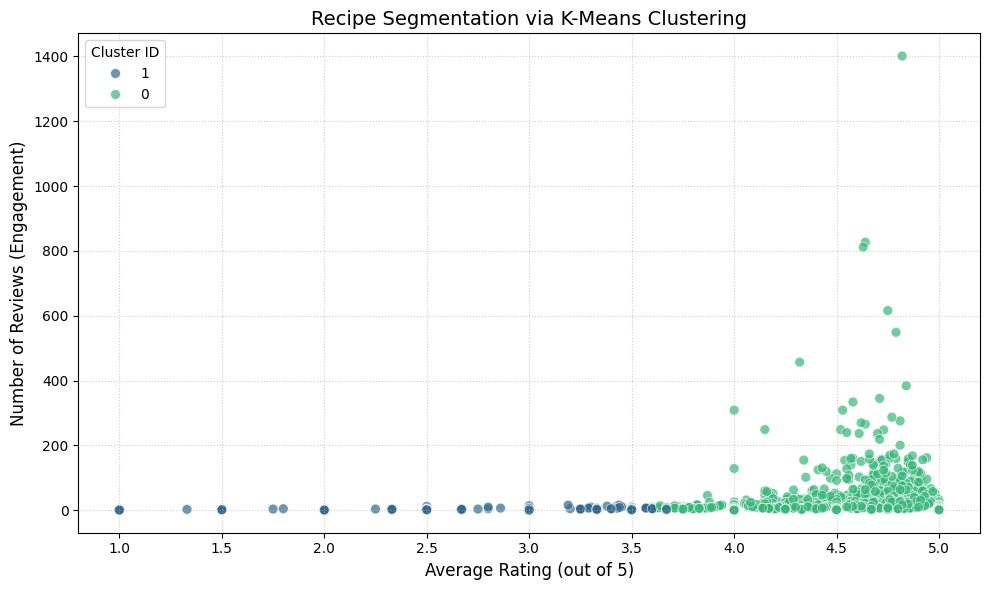

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import avg, round

# Compute Cluster Profiles & Summary Statistics
print("K-Means Recipe Cluster Profiles:")

# Calculate average rating and average review count for each cluster
cluster_analysis = (
    predictions.groupBy("prediction")
    .agg(
        round(avg("avg_rating"), 2).alias("cluster_avg_rating"),
        round(avg("review_count"), 2).alias("cluster_avg_reviews"),
    )
    .orderBy("prediction")
)

cluster_analysis.show(truncate=False)

# Extract Sample to Pandas for Scatter Plot
# Sample 10% of predictions for clean, performant visualization
pd_res = (
    predictions.select("avg_rating", "review_count", "prediction")
    .sample(withReplacement=False, fraction=0.1, seed=42)
    .toPandas()
)

# Ensure prediction is treated as a categorical column for distinct legend colors
pd_res["prediction"] = pd_res["prediction"].astype(str)

#  Scatter Plot Visualization
plt.figure(figsize=(10, 6))

# Plot rating vs review count colored by assigned K-Means cluster
sns.scatterplot(
    data=pd_res,
    x="avg_rating",
    y="review_count",
    hue="prediction",
    palette="viridis",
    alpha=0.7,
    s=50,
)

plt.title("Recipe Segmentation via K-Means Clustering", fontsize=14)
plt.xlabel("Average Rating (out of 5)", fontsize=12)
plt.ylabel("Number of Reviews (Engagement)", fontsize=12)
plt.legend(title="Cluster ID", loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

###Part B

Food enthusiasts and home cooks often struggle to decide "what to cook next" once they find a recipe they love. Traditional recommendation systems rely heavily on historical user ratings and reviews (Collaborative Filtering), creating a "cold start" issue for new or unrated dishes. To resolve this, I incorporated Natural Language Processing (NLP) to analyze recipe descriptions, ingredient lists, tags, and preparation steps. By computing text-based feature vectors, the system can instantly recommend highly relevant, niche, or newly added recipes based on content similarity even if they have zero user ratings.

I utilized a comprehensive dataset of 200,000+ Food.com recipes, building TF-IDF text features from recipe tags and ingredients and using cosine similarity to build a content-based recommendation pipeline. ALS collaborative filtering (for personalised recommendations) is left as future work.

In [34]:
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import col, udf, desc, lit
from pyspark.sql.types import FloatType
import numpy as np

In [35]:
from pyspark.ml.feature import HashingTF, IDF, Normalizer
from pyspark.sql import functions as F
from pyspark.sql.functions import col

# --- Recipe-level weighted rating (used to rank tag suggestions fairly) ---
M_REC = 20
global_avg_recipe = df_clean.agg(F.avg("rating")).first()[0]

recipe_stats_df = final_df.select("recipe_id", "name", "avg_rating", "review_count").withColumn(
    "weighted_rating",
    F.round(
        (col("review_count") / (col("review_count") + F.lit(M_REC))) * col("avg_rating")
        + (F.lit(M_REC) / (col("review_count") + F.lit(M_REC))) * F.lit(global_avg_recipe),
        2,
    ),
)

# --- Text content of each recipe: tags + ingredients (cleaned) ---
content_df = (
    recipes_with_tags.join(recipe_stats_df, on="recipe_id", how="inner")
    .withColumn(
        "text",
        F.concat_ws(
            ",",
            col("tags"),
            F.regexp_replace(F.coalesce(col("ingredients"), F.lit("")), r"[\[\]']", ""),
        ),
    )
    .withColumn(
        "terms",
        F.filter(F.transform(F.split(col("text"), ","), lambda x: F.trim(x)), lambda x: x != ""),
    )
)

# --- TF-IDF, then L2-normalise so that cosine similarity = dot product ---
tf_df = HashingTF(inputCol="terms", outputCol="tf", numFeatures=2**14).transform(content_df)
idf_model = IDF(inputCol="tf", outputCol="tfidf").fit(tf_df)
content_df = (
    Normalizer(inputCol="tfidf", outputCol="content_features", p=2.0)
    .transform(idf_model.transform(tf_df))
    .select("recipe_id", "name", "tags", "avg_rating", "review_count", "weighted_rating", "content_features")
    .cache()
)

print(f"Recipes with TF-IDF content vectors: {content_df.count():,}")

Recipes with TF-IDF content vectors: 226,590


In [36]:
from pyspark.sql.functions import col, desc
from pyspark.sql.types import FloatType


def get_recipe_recommendations(recipe_name, top_n=5, tag=None, min_reviews=20):
    """Recommend recipes whose tags + ingredients are most similar (TF-IDF cosine)."""
    name = recipe_name.lower().strip()

    target_row = (
        content_df.filter(col("name") == name)
        .select("content_features")
        .limit(1)
        .collect()
    )
    if not target_row:
        return f"Recipe '{recipe_name}' not found."

    target_vec = target_row[0][0]

    # Vectors are L2-normalised, so the dot product IS the cosine similarity
    @F.udf(FloatType())
    def similarity(vec):
        return float(vec.dot(target_vec)) if vec is not None else 0.0

    candidates = content_df.filter((col("name") != name) & (col("review_count") >= min_reviews))
    if tag:
        # filter by tag BEFORE taking top_n, so we always return top_n results if they exist
        candidates = candidates.filter(F.lower(col("tags")).contains(tag.lower().strip()))

    return (
        candidates.withColumn("similarity_score", similarity(col("content_features")))
        .select("name", "tags", "avg_rating", "review_count", "similarity_score")
        .orderBy(desc("similarity_score"), desc("review_count"))
        .limit(top_n)
    )


# Example test run: recipes similar to a popular recipe
recipe_recs = get_recipe_recommendations("best banana bread", top_n=5)

if isinstance(recipe_recs, str):
    print(recipe_recs)
else:
    recipe_recs.show(truncate=False)

+---------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+------------+----------------+
|name                             |tags                                                                                                                                                                                                                                                                                                 |avg_rating|review_count|similarity_score|
+---------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [37]:
from pyspark.sql.functions import col, desc, lower


def suggest_by_tag(user_input_tag, top_n=5, min_reviews=20):
    tag = user_input_tag.lower().strip()

    suggestions = content_df.filter(
        lower(col("tags")).contains(tag) & (col("review_count") >= min_reviews)
    )

    if suggestions.limit(1).count() == 0:
        return f"No recipes found for category/tag: {user_input_tag}"

    # Rank by weighted rating so a 5.0 from 1 review can't beat a 4.7 from 500 reviews
    return (
        suggestions.orderBy(desc("weighted_rating"), desc("review_count"))
        .select("name", "tags", "avg_rating", "review_count", "weighted_rating")
        .limit(top_n)
    )

In [38]:
from pyspark.sql.functions import col, explode, regexp_replace, split, trim

# Join final_df with recipes_with_tags to ensure 'tags' column is present
# This assumes recipes_with_tags is available from previous cells.
df_with_tags_for_search = final_df.join(recipes_with_tags, on="recipe_id", how="inner")

# Clean stringified array representation e.g. "['dessert', 'baking']" -> "dessert, baking"
cleaned_tags_df = df_with_tags_for_search.withColumn(
    "clean_tags", regexp_replace(col("tags"), r"\[|\]|'|\"", "")
)

# Split tags into individual rows to identify distinct categories
distinct_tags = (
    cleaned_tags_df.withColumn("tag_individual", explode(split(col("clean_tags"), ",")))
    .withColumn("tag_individual", trim(col("tag_individual")))
    .select("tag_individual")
    .distinct()
    .orderBy("tag_individual")
)

print("____ Food.com Recipe Tag/Category Types ____")
# Collect distinct tags to a local Python list
tag_list = [row["tag_individual"] for row in distinct_tags.collect()]

# Display preview of top 50 unique tags
print("Sample of Available Tags:")
print(", ".join(tag_list[:50]))

print()
user_tag = input("\nWhat kind of recipe or cuisine do you want to search for? ")

# Input validation loop for top_n
while True:
    try:
        top_n_input = input("How many suggestions (as a number) do you want? ")
        top_n = int(top_n_input)
        break
    except ValueError:
        print("Invalid input. Please enter a whole number for the number of suggestions.")

print(f"\nTop {top_n} '{user_tag}' recipes based on your preference:")
results = suggest_by_tag(user_tag, top_n)

if isinstance(results, str):
    print(results)
else:
    results.show(truncate=False)

____ Food.com Recipe Tag/Category Types ____
Sample of Available Tags:
, 1-day-or-more, 15-minutes-or-less, 3-steps-or-less, 30-minutes-or-less, 4-hours-or-less, 5-ingredients-or-less, 60-minutes-or-less, Throw the ultimate fiesta with this sopaipillas recipe from Food.com., a1-sauce, african, american, amish-mennonite, angolan, appetizers, apples, april-fools-day, argentine, artichoke, asian, asparagus, australian, austrian, avocado, bacon, baja, baked-beans, baking, bananas, bar-cookies, barbecue, bass, bean-soup, beans, beans-side-dishes, bear, beef, beef-barley-soup, beef-kidney, beef-liver, beef-organ-meats, beef-ribs, beef-sauces, beef-sausage, beginner-cook, beijing, belgian, berries, beverages, birthday


What kind of recipe or cuisine do you want to search for? Pasta
How many suggestions (as a number) do you want? 15

Top 15 'Pasta' recipes based on your preference:
+--------------------------------------------------------------+------------------------------------------------

In [39]:
def recommend_similar_in_tag(target_recipe, target_tag, top_n=5):
    # Tag filter is applied inside the similarity search (before top_n), not after a top-1000 cut
    recs = get_recipe_recommendations(target_recipe, top_n=top_n, tag=target_tag)

    if isinstance(recs, str):
        return recs

    if recs.limit(1).count() == 0:
        return f"No similar recipes found with the tag '{target_tag}' for '{target_recipe}'."

    return recs

In [40]:
# Execution
target_recipe = input("What recipe do you like? ")
target_tag = input("What kind of tag/cuisine do you like? ")

result = recommend_similar_in_tag(target_recipe, target_tag)

if isinstance(result, str):
    print(result)
else:
    result.show(truncate=False)

What recipe do you like? quinoa toasted 
What kind of tag/cuisine do you like? american
+---------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+------------+----------------+
|name                                   |tags                                                                                                                                                                                                                                                                                                                                                                                       

###Discussion of key findings, limitations, and possible improvements

Key Findings

Big Dataset Handled: The system processed over 1.13 million interaction records easily and linked them with recipe tags to see rating patterns.

Niche Tags Score Highest: Specific or event-based tags (like 'eggs-dairy' or 'memorial-day') got the highest average ratings, scoring high between 4.78 and 4.93 out of 5.

Clean Data Pipeline: Using simple cleaning functions (try_cast and fillna()), the pipeline dropped rows with missing values and excluded 0-star (unrated) reviews.

Limitations

Messy Tag Text: Basic text splitting left annoying extra symbols (like quotes ' and brackets ]), forcing extra manual cleanup later.

Small Sample Bias: Even after removing tags with fewer than 10 ratings, rare tags with very few ratings still ranked higher than popular ones.

No Personalized Recommendations: The system only calculates simple average scores it doesn't actually predict what individual users will like.

Possible Improvements

Better Text Cleaning: Clean up unwanted quotes and brackets directly inside PySpark before splitting the tags.

Fairer Score System: Use a weighted rating system (like IMDb uses) so tags with very few reviews don't unfairly top the list.

Build a Recommendation Model: Train a proper recommendation model (using Spark’s ALS algorithm) to suggest recipes based on user tastes.

In this project, I built a scalable data analysis pipeline in Google Colab using PySpark to analyze user ratings and recipe preferences. I worked with two main datasets: RAW_interactions.csv, which contained over 1.13 million user interaction records, and RAW_recipes.csv, which contained over 230,000 unique recipes along with their specific tag categories. I first loaded and cleaned the interactions data by applying standardized casting and filling routines (try_cast and fillna()) across key columns specifically user_id, recipe_id, and rating—to ensure there were no missing or null values. Once the dataset was clean, I merged the interaction records with the recipe tags dataset on recipe_id to analyze how different culinary categories performed across the total rating counts.

Through my analysis, I discovered that hyper specific and event driven tags consistently achieved the highest average scores, sitting between 4.78 and 4.93 out of 5.0. However, I also ran into a few practical limitations. Parsing the raw tag strings left behind unwanted formatting artifacts like brackets and quotation marks, which required extra cleanup in Pandas before I could plot the data cleanly. Furthermore, even though I filtered out tags with fewer than 10 recipes, the top rankings were still slightly biased toward niche items with small review counts rather than widely popular recipes. Finally, because my current work focused on descriptive statistics (average ratings per tag), my pipeline lacked a predictive system to suggest recipes to individual users, pointing to future opportunities like implementing PySpark’s ALS algorithm for collaborative filtering and using a weighted rating system to balance review counts fairly